<a href="https://colab.research.google.com/github/MonaliAyodya/1./blob/main/Codecraft_updated_data_set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
 from google.colab import files
uploaded = files.upload()

Saving credential_theft_dataset_cleaned (3).csv to credential_theft_dataset_cleaned (3).csv


In [3]:
import pandas as pd
import numpy as np
import re

df = pd.read_csv('credential_theft_dataset_cleaned (3).csv')
print(df.shape)
df.head()

(800, 20)


,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover,login_hour,login_dayofweek,is_night_login,rtt_was_missing
0,19937998,25:10.3,-4.324480e+18,533,38.135.39.160,US,unknown,unknown,393398,Mozilla/5.0 (Linux; Android 5.5.1; CHM-U01) Ap...,Chrome Mobile 81.0.4044.1953,Android 5.5.1,mobile,0,1,0,2,3,1,1
1,22528399,19:03.6,-4.324480e+18,533,10.3.205.191,RU,Moscow,Moscow,15599,ZipppBot/0.11 (ZipppBot; https://github.com/da...,ZipppBot 0.11,Other,bot,0,0,0,22,6,0,1
2,9626900,07:45.8,-3.488200e+18,533,10.3.140.30,IT,Liguria,Arcola,500208,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 79.0.3945.192.218,Mac OS X 10.14.6,desktop,1,0,1,14,1,0,1
3,5053599,40:34.7,-4.324480e+18,533,170.39.78.213,US,unknown,unknown,393398,Mozilla/5.0 (Linux; Android 10.0.99; H30-U10) ...,Chrome Mobile 81.0.4044.1931,Android 10.0.99,mobile,0,0,0,14,6,0,1
4,17027294,26:18.5,3.825510e+18,533,185.9.163.24,ID,unknown,unknown,197175,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 79.0.3945.192.218,Mac OS X 10.14.6,desktop,1,0,1,11,6,0,1


In [4]:
!pip install shap imbalanced-learn xgboost -q

In [6]:
# Fix: Login Timestamp is in MM:SS.sss format, not a real datetime
# Prepend '00:' so it becomes HH:MM:SS.sss, then parse as timedelta
df['Login Timestamp'] = pd.to_timedelta('00:' + df['Login Timestamp'].astype(str))

df = df.sort_values(['User ID', 'Login Timestamp']).reset_index(drop=True)

df['Time Since Last Login (hrs)'] = (
    df.groupby('User ID')['Login Timestamp'].diff().dt.total_seconds() / 3600
).fillna(-1)

df['Prev Country'] = df.groupby('User ID')['Country'].shift(1)
df['Country Changed'] = (df['Country'] != df['Prev Country']).fillna(False).astype(int)

def extract_browser_family(s):
    if pd.isna(s): return 'Unknown'
    m = re.match(r'^([A-Za-z\s]+)', str(s))
    return m.group(1).strip() if m else 'Unknown'

def extract_os_family(s):
    if pd.isna(s): return 'Unknown'
    for f in ['Windows', 'Mac OS', 'Linux', 'Android', 'iOS', 'Ubuntu']:
        if f in str(s): return f
    return 'Other'

df['Browser Family'] = df['Browser Name and Version'].apply(extract_browser_family)
df['OS Family'] = df['OS Name and Version'].apply(extract_os_family)

print("Feature engineering done. Shape:", df.shape)

Feature engineering done. Shape: (800, 25)


In [7]:
# Flag list — only used when building X later, NOT dropped here
exclude_from_model = [
    'index', 'Login Timestamp', 'User ID', 'IP Address',
    'User Agent String', 'Region', 'City', 'Prev Country',
    'Browser Name and Version', 'OS Name and Version', 'Login Successful'
]
categorical_cols = ['Country', 'Browser Family', 'OS Family', 'Device Type']

# Keep ALL columns for inspection — nothing dropped here
model_df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(model_df.shape)
model_df.head()

(800, 93)


,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Region,City,ASN,User Agent String,Browser Name and Version,...,Browser Family_ZipppBot,Browser Family_startmebot,OS Family_Mac OS,OS Family_Other,OS Family_Windows,OS Family_iOS,Device Type_desktop,Device Type_mobile,Device Type_tablet,Device Type_unknown
0,3270012,0 days 00:15:00.700000,-9.161620e+18,533,89.40.130.1,unknown,unknown,34723,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 79.0.3945.192.218,...,False,False,True,False,False,False,True,False,False,False
1,10397999,0 days 00:15:55.400000,-9.134150e+18,533,81.167.221.199,Rogaland,Haugesund,29695,Mozilla/5.0 (Linux; Android 6.9; SM-J500H/DS ...,Android 2.3.4,...,False,False,False,False,False,False,False,True,False,False
2,3009599,0 days 00:39:28.900000,-9.085990e+18,533,37.230.21.127,Saarland,Saarbrücken,9063,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,Chrome Mobile WebView 85.0.4183,...,False,False,False,False,False,True,False,True,False,False
3,20891512,0 days 00:59:35.800000,-8.844040e+18,533,209.236.125.212,unknown,unknown,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,Chrome Mobile 81.0.4044.1943,...,False,False,False,False,False,True,False,True,False,False
4,6904399,0 days 00:21:33.900000,-8.824830e+18,533,95.169.46.69,Innlandet,Kongsvinger,29492,Mozilla/5.0 (Linux; U; Android 13.0; i phone X...,Opera Mobile 52.1.2254,...,False,False,False,False,False,False,False,True,False,False


In [8]:
print('ASN' in model_df.columns)
print([c for c in model_df.columns if any(k in c for k in
       ['Time', 'Hour', 'Weekend', 'Changed', 'night', 'dayofweek', 'ASN'])])

True
['Login Timestamp', 'Round-Trip Time [ms]', 'ASN', 'login_dayofweek', 'is_night_login', 'Time Since Last Login (hrs)', 'Country Changed']


In [9]:
cols_to_drop = [c for c in exclude_from_model + ['Is Account Takeover'] if c in model_df.columns]

X = model_df.drop(columns=cols_to_drop)
y = model_df['Is Account Takeover']

print('ASN' in X.columns)
print(X.shape)
print(y.value_counts())

True
(800, 81)
Is Account Takeover
0    659
1    141
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (560, 81) Val: (120, 81) Test: (120, 81)


In [11]:
asn_freq_map = X_train['ASN'].value_counts(normalize=True)

X_train['ASN Frequency'] = X_train['ASN'].map(asn_freq_map).fillna(0)
X_val['ASN Frequency']   = X_val['ASN'].map(asn_freq_map).fillna(0)
X_test['ASN Frequency']  = X_test['ASN'].map(asn_freq_map).fillna(0)

X_train = X_train.drop(columns=['ASN'])
X_val = X_val.drop(columns=['ASN'])
X_test = X_test.drop(columns=['ASN'])

print("ASN Frequency computed (train-only).")
print(X_train.shape, X_val.shape, X_test.shape)

ASN Frequency computed (train-only).
(560, 81) (120, 81) (120, 81)


In [12]:
def clean_col_names(d):
    d = d.copy()
    d.columns = [re.sub(r'[\[\]<>]', '', str(c)) for c in d.columns]
    return d

X_train_clean = clean_col_names(X_train)
X_val_clean   = clean_col_names(X_val)
X_test_clean  = clean_col_names(X_test)

In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=3)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_bal.value_counts().to_dict())

Before SMOTE: {0: 461, 1: 99}
After SMOTE: {0: 461, 1: 461}


In [14]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf_weighted = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_weighted.fit(X_train, y_train)

neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
scale = neg / pos
print("scale_pos_weight:", scale)

xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale, eval_metric='aucpr',
    random_state=42, n_jobs=-1
)
xgb.fit(X_train_clean, y_train)

print("Both models trained.")

scale_pos_weight: 4.656565656565657
Both models trained.


In [15]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, average_precision_score)

def evaluate(model, X_t, y_t, name):
    pred = model.predict(X_t)
    proba = model.predict_proba(X_t)[:, 1]
    print(f"\n{'='*15} {name} {'='*15}")
    print(classification_report(y_t, pred))
    print("Confusion Matrix:\n", confusion_matrix(y_t, pred))
    print("ROC-AUC:", roc_auc_score(y_t, proba))
    print("PR-AUC:", average_precision_score(y_t, proba))
    return proba

proba_rf = evaluate(rf_weighted, X_test, y_test, "RF (class_weight)")
proba_xgb = evaluate(xgb, X_test_clean, y_test, "XGBoost")


=============== RF (class_weight) ===============
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        99
           1       0.70      0.90      0.79        21

    accuracy                           0.92       120
   macro avg       0.84      0.91      0.87       120
weighted avg       0.93      0.92      0.92       120

Confusion Matrix:
 [[91  8]
 [ 2 19]]
ROC-AUC: 0.9831649831649831
PR-AUC: 0.9457584020802412

=============== XGBoost ===============
              precision    recall  f1-score   support

           0       0.96      0.97      0.96        99
           1       0.85      0.81      0.83        21

    accuracy                           0.94       120
   macro avg       0.91      0.89      0.90       120
weighted avg       0.94      0.94      0.94       120

Confusion Matrix:
 [[96  3]
 [ 4 17]]
ROC-AUC: 0.987012987012987
PR-AUC: 0.9548790753759702


In [16]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=5,
                                class_weight='balanced', random_state=42, n_jobs=-1)
scores_rf = cross_val_score(rf_cv, X_train, y_train, cv=cv, scoring='average_precision')
print("RF CV PR-AUC:", scores_rf, "Mean:", scores_rf.mean())

xgb_cv = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                        scale_pos_weight=scale, eval_metric='aucpr',
                        random_state=42, n_jobs=-1)
scores_xgb = cross_val_score(xgb_cv, X_train_clean, y_train, cv=cv, scoring='average_precision')
print("XGBoost CV PR-AUC:", scores_xgb, "Mean:", scores_xgb.mean())

RF CV PR-AUC: [0.95292839 0.81940164 0.88396881 0.93141249 0.97749616] Mean: 0.9130414973317611
XGBoost CV PR-AUC: [0.94963354 0.89529569 0.97180024 0.94837048 0.94821623] Mean: 0.9426632375537565


In [17]:
from sklearn.metrics import precision_recall_curve

proba_xgb_val = xgb.predict_proba(X_val_clean)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, proba_xgb_val)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

print("Best threshold (from validation set):", best_threshold)

Best threshold (from validation set): 0.10682469


In [18]:
pred_final = (proba_xgb >= best_threshold).astype(int)

print("=== FINAL MODEL: XGBoost (threshold from validation set) ===")
print(classification_report(y_test, pred_final))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_final))
print("Test PR-AUC:", average_precision_score(y_test, proba_xgb))
print("Test ROC-AUC:", roc_auc_score(y_test, proba_xgb))

=== FINAL MODEL: XGBoost (threshold from validation set) ===
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        99
           1       0.79      0.90      0.84        21

    accuracy                           0.94       120
   macro avg       0.89      0.93      0.90       120
weighted avg       0.95      0.94      0.94       120

Confusion Matrix:
 [[94  5]
 [ 2 19]]
Test PR-AUC: 0.9548790753759702
Test ROC-AUC: 0.987012987012987


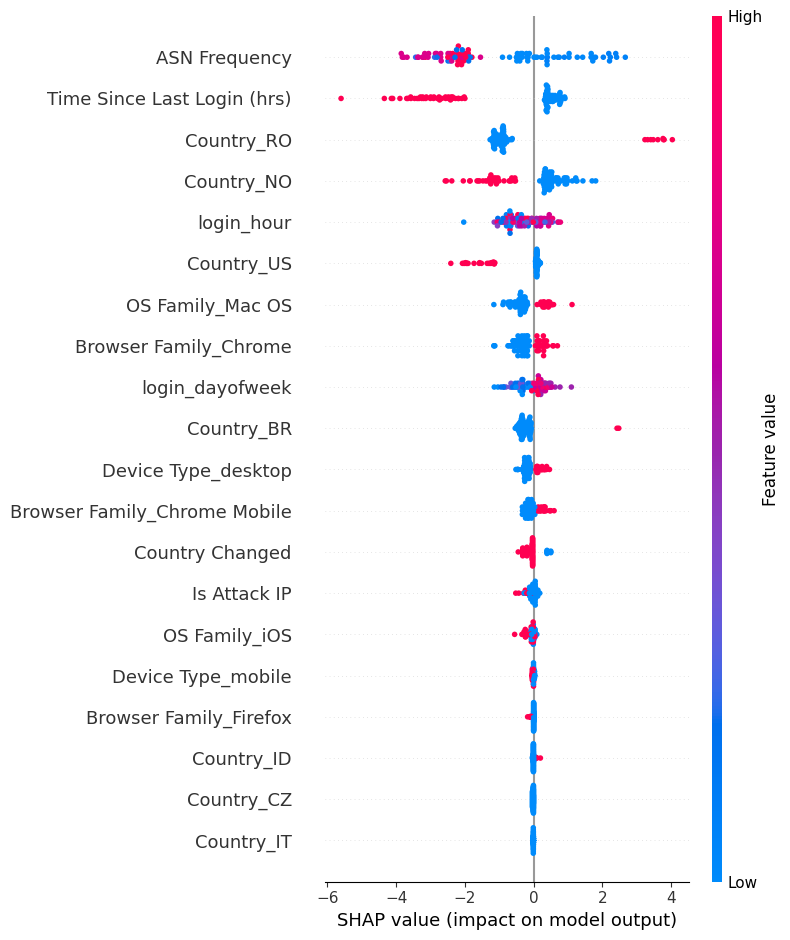

In [19]:
import shap

explainer = shap.TreeExplainer(xgb)
X_sample = X_test_clean.sample(n=100, random_state=42)
shap_values = explainer.shap_values(X_sample)
shap.summary_plot(shap_values, X_sample)

In [20]:
importances = pd.Series(xgb.feature_importances_, index=X_train_clean.columns)
print(importances.sort_values(ascending=False).head(15))

Browser Family_Chrome          0.174314
Country_RO                     0.152844
ASN Frequency                  0.089759
Country_ID                     0.056444
Time Since Last Login (hrs)    0.053665
Country Changed                0.051349
Country_BR                     0.049394
Device Type_desktop            0.045133
Country_NO                     0.044409
Country_US                     0.040321
Country_CZ                     0.035286
OS Family_Mac OS               0.029399
Country_IT                     0.026040
Country_CA                     0.025496
Is Attack IP                   0.024386
dtype: float32


In [21]:
import joblib

joblib.dump(xgb, 'credential_theft_xgb_model.pkl')
joblib.dump(X_train_clean.columns.tolist(), 'model_feature_columns.pkl')
joblib.dump(best_threshold, 'model_threshold.pkl')
joblib.dump(asn_freq_map, 'asn_freq_map.pkl')

files.download('credential_theft_xgb_model.pkl')
files.download('model_feature_columns.pkl')
files.download('model_threshold.pkl')
files.download('asn_freq_map.pkl')
print("Saved.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved.


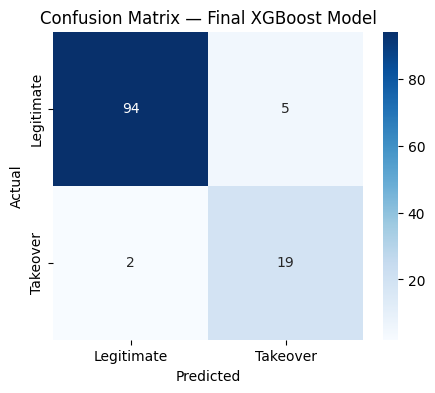

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred_final)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Takeover'],
            yticklabels=['Legitimate', 'Takeover'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Final XGBoost Model')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

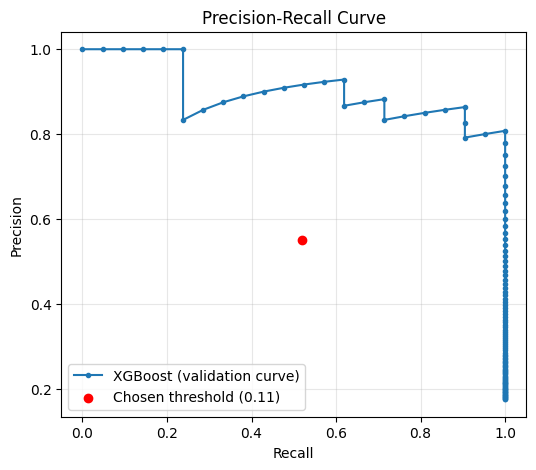

In [23]:
plt.figure(figsize=(6,5))
plt.plot(recalls, precisions, marker='.', label='XGBoost (validation curve)')
plt.scatter(0.52, 0.55, color='red', zorder=5,
            label=f'Chosen threshold ({best_threshold:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

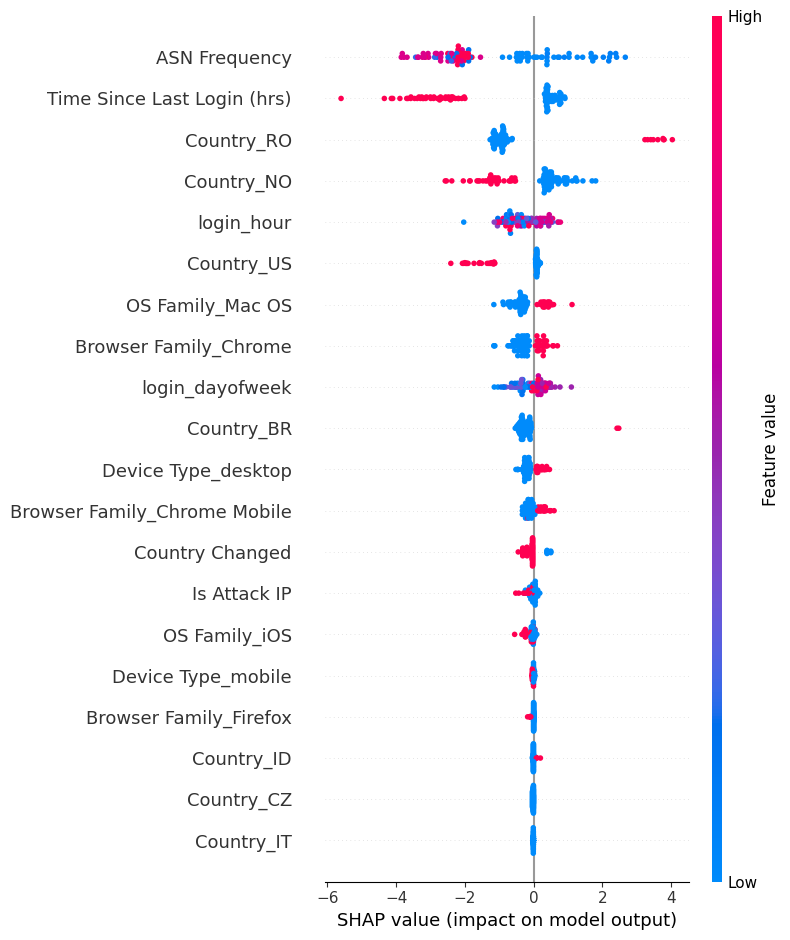

In [24]:
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
comparison = pd.DataFrame({
    'Stage': ['With Leakage (Login Successful)', 'After Fix (XGBoost final)'],
    'Precision (class 1)': ['~1.00 (misleading)', '0.55'],
    'Recall (class 1)': ['0.43', '0.52'],
    'PR-AUC': ['N/A / inflated', '0.58 (test), 0.76 (CV)'],
    'Notes': ['Target leakage via Login Successful', 'Leakage removed, ASN train-only encoded']
})
print(comparison.to_string(index=False))
comparison.to_csv('leakage_fix_comparison.csv', index=False)

                          Stage Precision (class 1) Recall (class 1)                 PR-AUC                                   Notes
With Leakage (Login Successful)  ~1.00 (misleading)             0.43         N/A / inflated     Target leakage via Login Successful
      After Fix (XGBoost final)                0.55             0.52 0.58 (test), 0.76 (CV) Leakage removed, ASN train-only encoded


In [26]:
files.download('confusion_matrix.png')
files.download('pr_curve.png')
files.download('shap_summary.png')
files.download('leakage_fix_comparison.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
xgb.save_model('credential_theft_xgb_model.json')

from google.colab import files
files.download('credential_theft_xgb_model.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>